# Function 8 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 8** in Week 1. We examine the initial datapoints to understand the relationship between inputs (x1, x2, x3, x4, x5, x6, x7, x8) and the output (y), then use Bayesian optimization to find promising regions for further exploration.

**Function Description:** You're optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. Your objective is to find the parameter combination that maximises the function's output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.


## Loading and Displaying the Data

We load the initial inputs and outputs for function 8 and display them in a table format to inspect the raw data values.


In [14]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_8")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,x7,x8,y
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


df sorted by y


,x1,x2,x3,x4,x5,x6,x7,x8,y,x_avg
0,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482,0.046030
1,0.192640,0.630677,0.416796,0.490529,0.796086,0.654567,0.276241,0.295518,9.344274,0.432661
2,0.481245,0.102461,0.219486,0.677322,0.247509,0.244341,0.163825,0.715962,9.183005,0.370129
3,0.145120,0.119328,0.420888,0.387609,0.155423,0.875172,0.510560,0.728611,9.141639,0.268236
4,0.044329,0.013581,0.258198,0.577644,0.051280,0.158563,0.591030,0.077953,9.013075,0.223438
5,0.143550,0.937415,0.232325,0.009043,0.414579,0.409325,0.553779,0.205841,8.976554,0.330583
6,0.028947,0.028279,0.481372,0.613175,0.672660,0.022113,0.601483,0.524885,8.830745,0.287943
7,0.338954,0.566932,0.376751,0.098916,0.659452,0.245548,0.762483,0.732153,8.817558,0.345388
8,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117,0.453549
9,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748,0.409937


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, x4, x5, x6, x7, x8, and y). The heatmap shows strong negative correlations of x1 and x3 with y (-0.63 and -0.62) while the correlation between x1 and x3 is close to zero. 

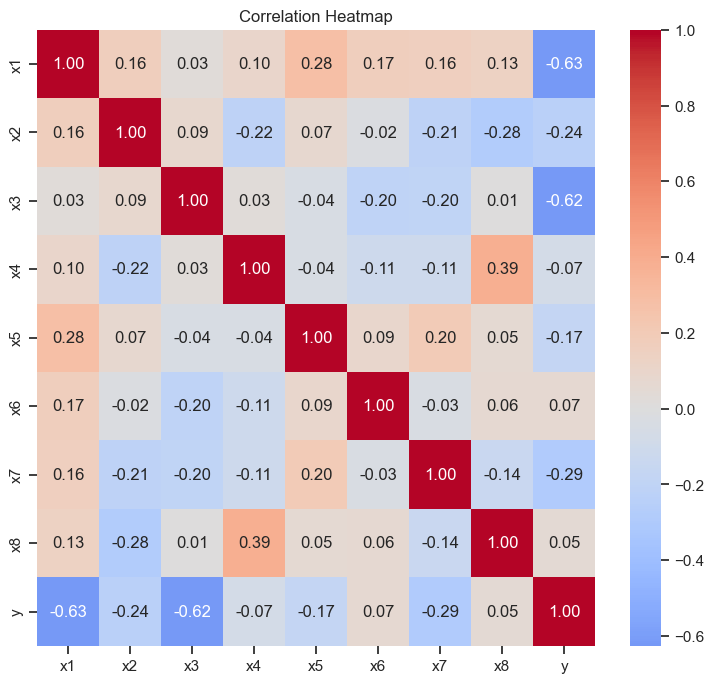

In [15]:
plt.figure(figsize=(9, 8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables. The diagonal shows distributions (histograms), while off-diagonal plots show scatter plots. This helps identify patterns, clusters, and potential non-linear relationships that might not be captured by correlation alone.


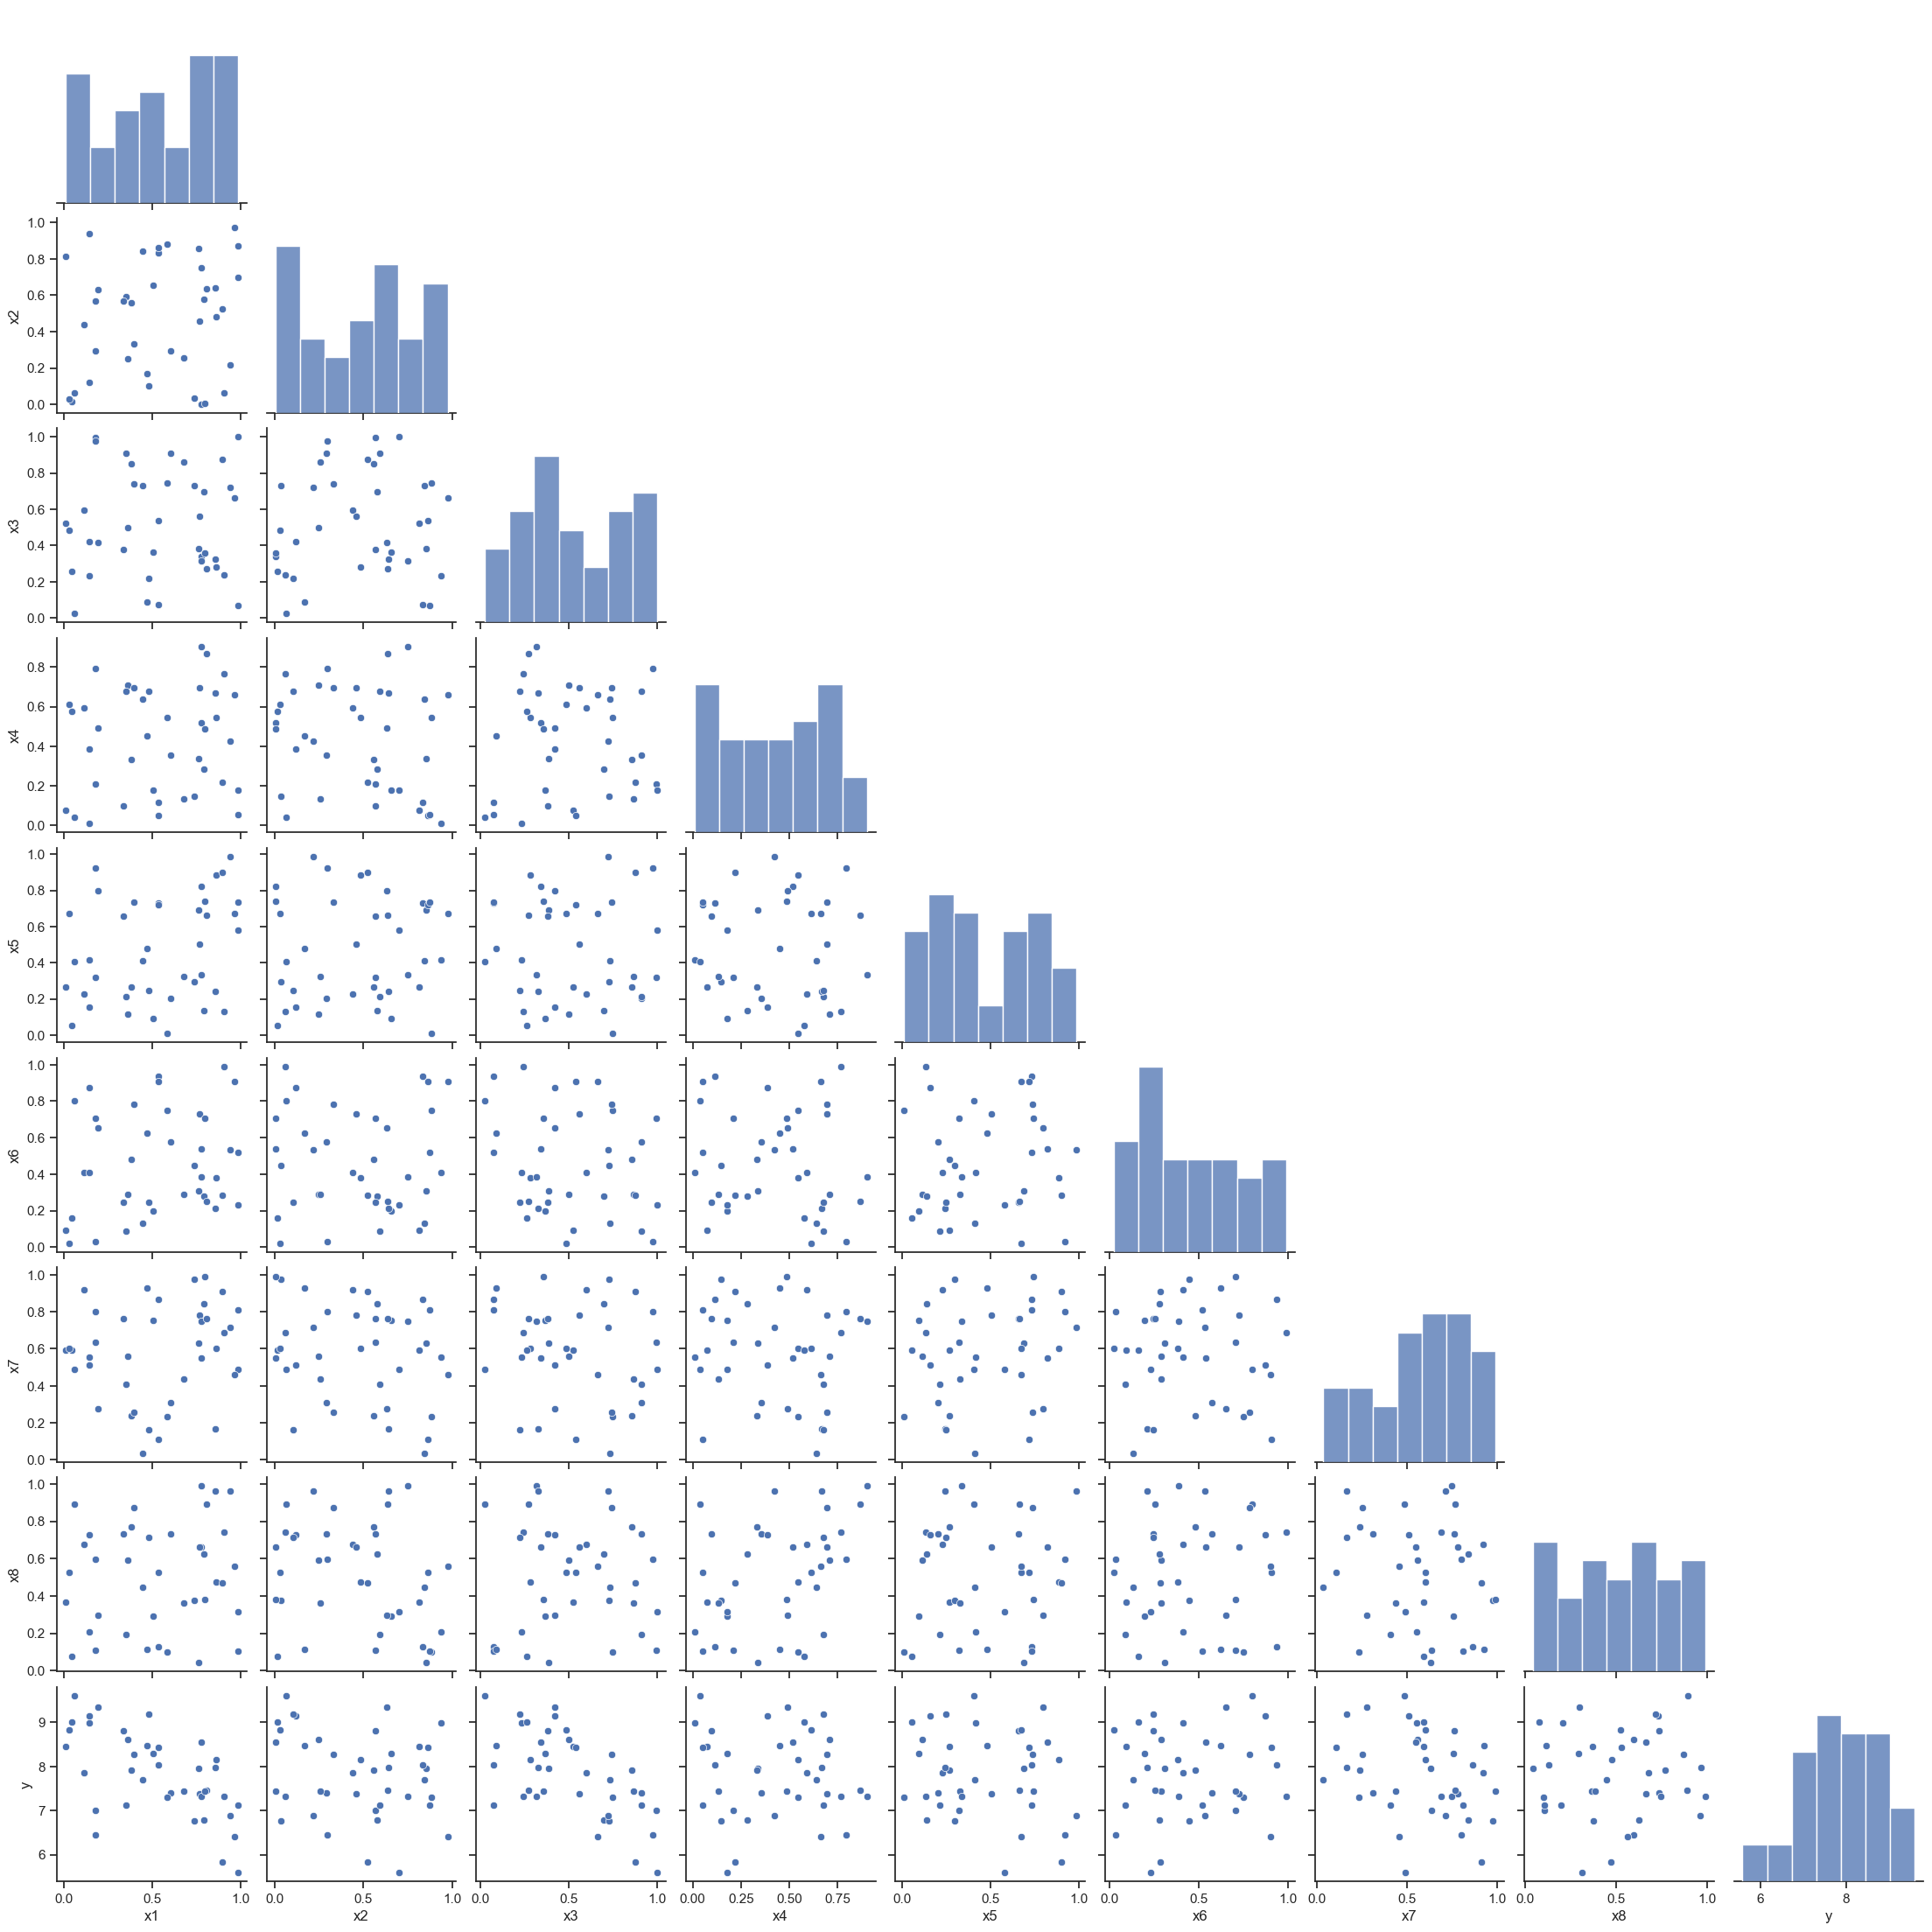

In [16]:
sns.pairplot(df, corner=True, diag_kind="hist")
plt.show()


## Conclusion from Exploratory Analysis

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the eight input parameters. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas.


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. We use the Upper Confidence Bound (UCB) acquisition function to balance exploration (high uncertainty) and exploitation (high predicted mean). The search space is defined as [0, 1] for each of the eight input variables.


In [17]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.11579874 1.7053212  0.81275796 2.4827749  3.80198707 5.
 1.13757717 5.        ]
Full kernel parameters: {'length_scale': array([1.11579874, 1.7053212 , 0.81275796, 2.4827749 , 3.80198707,
       5.        , 1.13757717, 5.        ]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Finding the Next Point to Evaluate

We optimize the Upper Confidence Bound (UCB) acquisition function: UCB(x) = μ(x) + κ·σ(x), where μ(x) is the predicted mean, σ(x) is the predicted standard deviation, and κ is a parameter controlling the exploration-exploitation trade-off. A higher κ favors exploration, while a lower κ favors exploitation. We use κ=2.0 to balance both objectives.


In [18]:
kappa = 2.0
def ucb(x):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    return -(mu + kappa * sigma)
bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]
result = minimize(ucb, x0=np.random.uniform(0, 1, 8), bounds=bounds, method='L-BFGS-B')
next_point = result.x
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)
print(f"Next point to evaluate: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}, x7={next_point[6]:.4f}, x8={next_point[7]:.4f}")
print(f"Predicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"UCB value: {mu_pred[0] + kappa * sigma_pred[0]:.4f}")


Next point to evaluate: x1=0.0399, x2=0.0000, x3=0.1137, x4=0.0000, x5=1.0000, x6=0.9283, x7=0.0000, x8=0.0000
Predicted output: 9.8015 ± 0.3873
UCB value: 10.5762


## Distance Analysis of Recommended Point

We calculate the Euclidean distance from the recommended point to all existing observations. This helps us understand how similar the recommended point is to our existing data. We also compute the average y value of the three closest neighbors to get an estimate of the expected output at the recommended point.


In [19]:
distances = np.sqrt(((X - next_point)**2).sum(axis=1))
df_dist = pd.DataFrame({"point_index": range(len(X)), "distance": distances, "y": y})
df_dist = df_dist.sort_values("distance")
print("Euclidean distances from recommended point to all observations:")
print(df_dist.to_string(index=False))
closest_3 = df_dist.head(3)
avg_y = closest_3["y"].mean()
print(f"\nThree closest neighbors: points {closest_3['point_index'].tolist()}")
print(f"Average y value of closest 3 neighbors: {avg_y:.4f}")


Euclidean distances from recommended point to all observations:
 point_index  distance        y
          26  1.016718 9.344274
          14  1.192438 9.598482
          31  1.239330 8.421759
          35  1.288280 8.472936
          22  1.333258 9.141639
           5  1.338215 8.541748
          28  1.339077 8.042213
          12  1.365562 8.976554
          32  1.424699 8.278062
          25  1.441437 8.830745
           1  1.444398 7.005227
          38  1.454792 7.436594
          15  1.460684 8.159983
          23  1.479660 8.817558
          19  1.484169 9.013075
          18  1.496416 7.433744
          39  1.499579 9.183005
           8  1.521726 7.957875
          30  1.572363 7.923759
           2  1.599024 8.459482
           0  1.600022 7.398721
          33  1.602369 7.113457
           4  1.633569 8.606117
          17  1.644770 6.767963
           3  1.658614 8.284008
          13  1.663037 7.379083
           7  1.687261 7.299872
          29  1.687841 7.692368
        

## Analysis and Recommendation

This is a pure black box optimisation in high dimensional space. We used a "standard" Bayesian optimisation to model this. The next recommended point is x1=0.0399, x2=0.0000, x3=0.1137, x4=0.0000, x5=1.0000, x6=0.9283, x7=0.0000, x8=0.0000. Checking against our best point, the GP has learned "low x1–x4, high x6" but is suggesting extreme values (0.0, 1.0) for x5, x7, x8, regions with little data and big differences to our best point, suggesting the model is exploring. The predicted y is 9.8015 with a high error of 0.3873. More data seems to be needed to get more confident. We decide to be a bit more conservative, keeping x1–x4 and x6 close the GP, but moderating x5, x7, x8 away from extremes: [0.05, 0.05, 0.05, 0.05, 0.60, 0.93, 0.25, 0.45]